# Exploratory Data Analysis

## Libraries

In [6]:
from pathlib import Path

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Declarations

In [8]:
FOLDER_NAME = "parquet"

### Parquet Processor

In [9]:
def process_parquet_files(parquet_folder, process_func, *args, **kwargs):
    """
    Process all Parquet files in a folder using a custom function.

    Parameters
    ----------
    parquet_folder : str
        Folder containing Parquet files.
    process_func : callable
        Function that accepts a DataFrame as its first argument.
    *args, **kwargs :
        Additional arguments passed to process_func.

    Returns
    -------
    list of results returned by process_func.
    """

    parquet_files = sorted(Path(parquet_folder).glob("*.parquet"))

    if not parquet_files:
        raise FileNotFoundError("No Parquet files found.")

    results = []

    total = len(parquet_files)

    for i, file in enumerate(parquet_files, start=1):
        print(f"Processing [{i}/{total}] {file.name}...", end="\r", flush=True)

        df = pd.read_parquet(file)

        result = process_func(df, *args, **kwargs)
        results.append(result)

    print(" " * 100, end="\r")
    print(f"Finished processing all files: {process_func.__name__}")

    return results

## Count Total Rows

In [10]:
def count_total_rows(df:pd.DataFrame):
    return len(df)

In [11]:
def analyze_total_rows(folder_name:str):
    return sum(process_parquet_files(folder_name, count_total_rows))

In [12]:
TOTAL_ROWS = analyze_total_rows(FOLDER_NAME)
print(f"Total rows: {TOTAL_ROWS}")

Finished processing all files: count_total_rows                                                     
Total rows: 16233002


## Missing Values

In [13]:
def count_missing_values(df: pd.DataFrame):
    return df.isna().sum()

In [14]:
def analyze_missing_values(folder_name: str) -> pd.DataFrame:
    missing_values = (
        pd.concat(
            process_parquet_files(folder_name, count_missing_values),
            axis=1
        )
        .fillna(0)
        .sum(axis=1)
        .to_frame(name="Missing Count")
        .sort_values(by="Missing Count", ascending=False)
    )

    missing_values["Missing Percentage"] = (
        missing_values["Missing Count"] / TOTAL_ROWS * 100
    ).round(4)

    return missing_values

In [15]:
missing_values = analyze_missing_values(FOLDER_NAME)
missing_values.head()

Finished processing all files: count_missing_values                                                 


,Missing Count,Missing Percentage
Flow Byts/s,59721.0,0.3679
Dst Port,0.0,0.0000
Timestamp,0.0,0.0000
Protocol,0.0,0.0000
Flow Duration,0.0,0.0000


## Class Distribution

In [16]:
def count_class_distribution(df: pd.DataFrame) -> pd.Series:
    return df["Label"].value_counts()

In [17]:
def analyze_class_distribution(folder_name: str) -> pd.DataFrame:
    results = process_parquet_files(folder_name, count_class_distribution)

    class_counts = pd.concat(results, axis=1).fillna(0).sum(axis=1)

    class_distribution = (
        class_counts
        .to_frame(name="Count")
        .sort_values("Count", ascending=False)
    )

    class_distribution["Percentage"] = (
        class_distribution["Count"] / class_distribution["Count"].sum() * 100
    ).round(4)

    return class_distribution

In [18]:
distribution = analyze_class_distribution(FOLDER_NAME)
distribution.head()

Finished processing all files: count_class_distribution                                             


,Count,Percentage
Label,,
Benign,13484708.0,83.0697
DDOS attack-HOIC,686012.0,4.2260
DDoS attacks-LOIC-HTTP,576191.0,3.5495
DoS attacks-Hulk,461912.0,2.8455
Bot,286191.0,1.7630


In [19]:
def plot_class_distribution_bar(
    class_distribution,
    count_col="Count",
    percentage_col="Percentage",
    figsize=(12, 8)
):
    """
    Plot class distribution as a horizontal bar chart.

    Parameters
    ----------
    class_distribution : pd.DataFrame
        Index contains class names.
        Must contain count_col and percentage_col.
    """

    df = class_distribution.sort_values(count_col, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.barh(
        df.index,
        df[count_col]
    )

    for bar, pct, cnt in zip(bars, df[percentage_col], df[count_col]):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f"Percentage: {pct:.2f}%\nCount: {cnt}",
            va="center",
            fontsize=9
        )

    ax.set_title("Class Distribution")
    ax.set_xlabel("Number of Samples")
    ax.set_ylabel("Attack Type")

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{int(x):,}")
    )
    plt.tight_layout()
    plt.show()

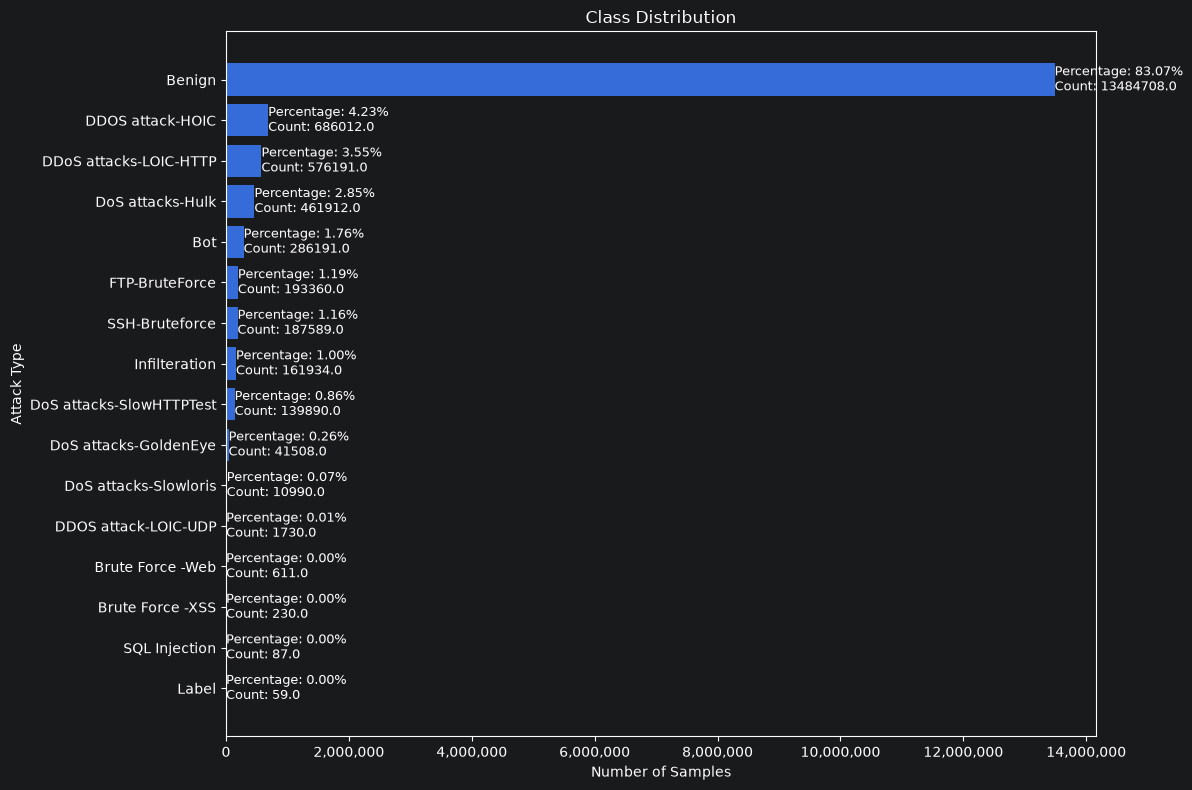

In [20]:
plot_class_distribution_bar(class_distribution=distribution)

### Duplicate Rows

In [28]:
def count_duplicate_row(df:pd.DataFrame):
    return df.duplicated().sum()

In [32]:
def analyze_duplicate_row(folder_name: str):
    duplicate_rows = process_parquet_files(folder_name, count_duplicate_row)
    return int(np.sum(duplicate_rows))

In [34]:
duplicate_rows = analyze_duplicate_row(FOLDER_NAME)
print(f"Duplicated rows: {duplicate_rows}")

Finished processing all files: count_duplicate_row                                                  
Duplicated rows: 383622
